In [87]:
import numpy as np
import csv
import matplotlib.pyplot as plt
refractive_index_path = "/content/drive/MyDrive/Summer 2026 ETOILES/Background Check Problems/Problem 1/Phillip.csv"
# Source: refractiveindex.info, covers 35 nm to 10 microns

from scipy.integrate import simpson

In [88]:
with open(refractive_index_path) as csvfile:
  reader = csv.reader(csvfile)
  refractive_index_array = []
  for row in reader:
    refractive_index_array.append(row)
  refractive_index_array.remove(refractive_index_array[177]) #remove the blank space row
  refractive_index_array = np.array(refractive_index_array) #convert from list to nparray
n_array = refractive_index_array[1:176].astype(np.float128) #chop out the headers
k_array = refractive_index_array[178:352].astype(np.float128)

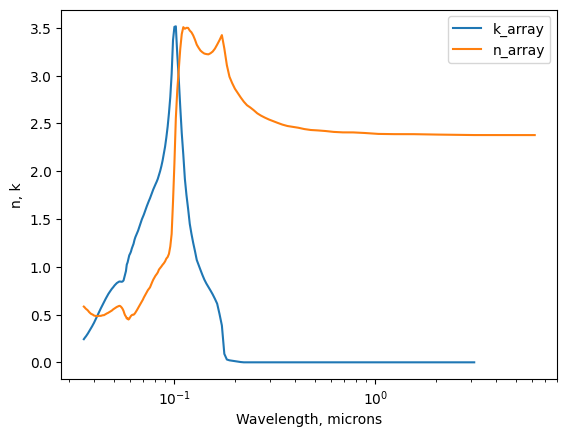

In [89]:
#Sanity plot of k_array vs frequency
plt.semilogx(k_array[:, 0], k_array[:,1], label="k_array")
plt.semilogx(n_array[:, 0], n_array[:,1], label="n_array")
plt.xlabel("Wavelength, microns")
plt.ylabel("n, k")
plt.legend()
plt.show()


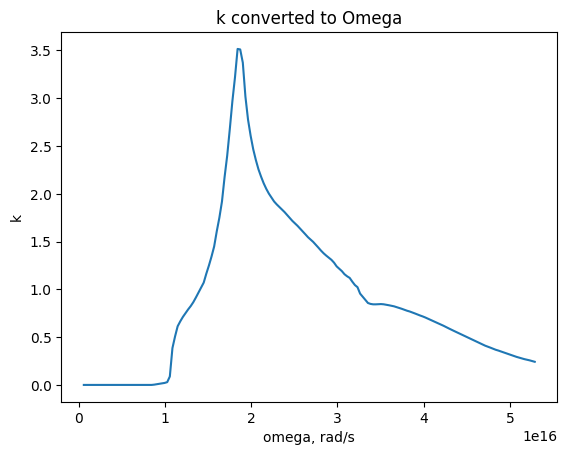

In [90]:
# in microns per second, c is 2.98 * 10**14
c = 2.98 * 10**14

#Convert k and n arrays to be with respect to omega
k_array_omega = np.flip(np.concatenate((2*np.pi*c/(k_array[:, 0]).reshape((-1, 1)), k_array[:, 1].reshape(-1,1)), axis=1), axis=0)
n_array_omega = np.flip(np.concatenate((2*np.pi*c/(n_array[:, 0]).reshape((-1, 1)), n_array[:, 1].reshape(-1,1)), axis=1), axis=0)
#Flip to undo the reversal of order because of the 1/x.

# print(k_array_omega)

plt.plot(k_array_omega[:,0], k_array_omega[:,1])
plt.title("k converted to Omega")
plt.xlabel("omega, rad/s")
plt.ylabel("k")
plt.show()


> From the paper by Philip and Taft, the desired Kramer-Kronig relation is
$$\theta(\omega_0) = \frac{1}{2\pi} \int_0^\infty \frac{d \ln R}{d \omega} \ln \left|\frac{\omega + \omega_0}{\omega - \omega_0} \right| d \omega,$$
Where $\theta$ is related to the desired $n$ by
$$\tan \theta = \frac{-2k}{n^2 + k^2 + 1}.$$
We have, from the Seret-Fresnel equations, that
$$R = \frac{n - 1}{n+1}.$$



Since we do not have $R$, we proceed using a different form of the Kramer-Kronig relations. From Wikipedia, we have
$$\chi_1(\omega) = \frac{2}{\pi} \int_0^\infty \frac{\omega' \chi_2(\omega') }{\omega'^2 - \omega^2} \, d\omega'.$$
where $\tilde{\chi} = \chi_1 + i\chi_2$ and $ \lim_{|\omega| \to \infty} \chi(\omega) = 0$.

The complex index of refraction $\tilde{N}(\omega) = n(\omega) + i k(\omega)$ has a limit of $1$, as imaginary part vanishes, and real part approaches $1$, i.e. index of refraction approaches vaccum. Thus, we have
$$n(\omega) = 1 + \frac{2}{\pi} \int_0^\infty \frac{\omega' k(\omega')}{\omega'^2 - \omega^2} d\omega'$$
from applying the kk relations to $\tilde{N}(\omega) - 1 = (n(\omega) - 1) + i k(\omega).$

Remark: $\tilde{N}(\omega)$ satisfies the relation requirements because $\tilde{N}(\omega) = \sqrt{1 + \tilde{\chi}(\omega)}$, and $\tilde{\chi}(\omega)$ is a response function relating the polarization response $\vec{P}$ to the electric field by $\vec{P} = \tilde{\chi} \epsilon_0 \vec{E}$. By Fouier analysis (see Wikipedia: Kramers Kronig relations), this implies that $\tilde{\chi}$ must be analytic in the upper half-plane. The application of the KK relations to $\tilde{N}(\omega) - 1$ is to satisfy the requirement of the KK relations that the function vanishes at infinity.

The plan is to
1) Interpolate the k values to a more uniform spacing in omega
2) Numerically integrate (KK integral) to compute the n value from the k value


I will first try numerically integrating without interpolating.

In [91]:
# n_array_computed_omega = np.array([[0,0]])
# for i in range(len(k_array_omega[:,0])-1):
#   omega = k_array_omega[i, 0]
#   integral_value = 0
#   integrate_array = np.delete(k_array_omega,i,0) #exclude the divide by zero region
#   for j in range(len(integrate_array[:,0])-1):
#     #trapezoid rule
#     domega = np.abs(integrate_array[j+1, 0] - integrate_array[j, 0])
#     integral_value += (1/2) * domega * ((integrate_array[j, 1]*integrate_array[j, 0])/(integrate_array[j, 0]**2 - omega**2) + (integrate_array[j+1, 1]*integrate_array[j+1, 0])/(integrate_array[j+1, 0]**2 - omega**2))
#   n_array_computed_omega = np.vstack((n_array_computed_omega, np.array([omega, integral_value])))
# n_array_computed_omega = np.delete(n_array_computed_omega, 0, 0)

In [92]:
# plt.plot(n_array_omega[:,0], n_array_omega[:, 1], label="actual")
# plt.plot(n_array_computed_omega[:,0], n_array_computed_omega[:,1], label="computed")
# plt.xlabel("omega, rad/s")
# plt.ylabel("n")
# plt.legend()
# plt.show()

I now will try interpolating to get a better match, and instead I'll use an out-of-the-box numerical integrator from Scipy.
We will evenly space in log frequency, since I think frequency is most naturally measured on a log scale.

In [93]:
# print(np.log(k_array_omega[0,0]))
# print(np.log(k_array_omega[-1,0]))
# x_values = np.flip(np.exp(np.arange(np.log(k_array_omega[-1,0]), np.log(k_array_omega[0,0]), 0.01)))
# interp_k = np.interp(x_values.astype(np.float64), k_array_omega[:, 0].astype(np.float64), k_array_omega[:, 1].astype(np.float64))
# interp_k_array = np.concatenate((np.reshape(x_values, (-1,1)),np.reshape(interp_k,(-1,1))),axis=1)

# plt.hist(x_values)
# plt.hist(k_array_omega[:,0])
# plt.show()

After trying the above and seeing how poorly the graphs match, I have chosen to evenly space in frequency instead of in log frequency. This is because our datapoints are more evenly distributed in frequency.

In [94]:
omega_values = np.arange(k_array_omega[0, 0], k_array_omega[-1, 0],1e13)
interp_k = np.interp(omega_values.astype(np.float64), k_array_omega[:, 0].astype(np.float64), k_array_omega[:, 1].astype(np.float64))
# interp_k_array = np.concatenate((np.reshape(omega_values, (-1,1)),np.reshape(interp_k,(-1,1))),axis=1)
# print(interp_k_array)


# plt.plot(interp_k_array[:,0], interp_k_array[:,1],)
# plt.plot(k_array_omega[:,0], k_array_omega[:,1])
# plt.show()

Interpolation is working now. Let's y to do numerical integration with the interpolated values by masking across the spike.



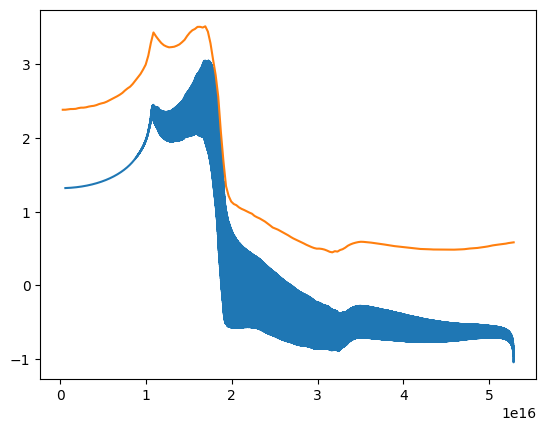

In [95]:
omega_simpson = np.array([])
for i in range(len(omega_values)):
  omega = omega_values[i]
  mask = ~((omega_values>omega - 0.5e13) & (omega_values < omega + 0.5e13))

  x_integrate = omega_values[mask]
  y_integrate = (interp_k[mask]*omega_values[mask])/(omega_values[mask]**2 - omega**2)

  omega_simpson = np.append(omega_simpson, (2/np.pi)*simpson(y_integrate,x_integrate))
plt.plot(omega_values, omega_simpson)
plt.plot(n_array_omega[:,0], n_array_omega[:, 1])
plt.show()

However, this computation is not very stable/accurate (i.e. "highly jagged" graph), so in the next cell, we will more carefully mask the spike, integrating from the -infty to the left value and from the right value to infty. This is in contrast to the current method, which integrates from -infty to infty and "cuts off the top of" the spike like it's a tree, leading to chaotic results.

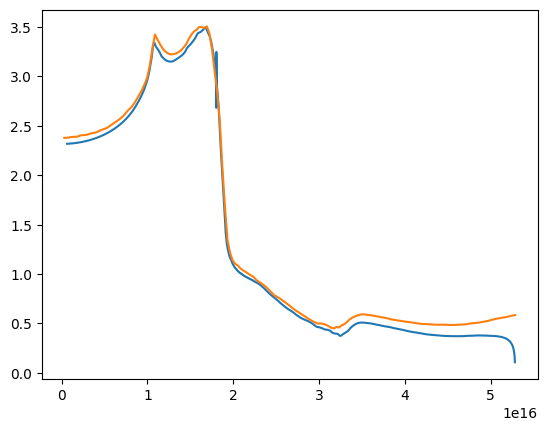

In [96]:
n_integrated_omega = np.array([])

delete_omega_values = np.array([])
for i in range(len(omega_values)):
  try:
    omega = omega_values[i]

    #mask out the x values which are within +- 3x10^13 of our pole
    left_mask = ~((omega_values < omega + 3e13))
    right_mask = ~((omega_values> omega - 3e13))

    #Integrate from -oo to the left mask and the right mask to oo
    x_right = omega_values[right_mask]
    y_right = (interp_k[right_mask]*omega_values[right_mask])/(omega_values[right_mask]**2 - omega**2)

    x_left = omega_values[left_mask]
    y_left = (interp_k[left_mask]*omega_values[left_mask])/(omega_values[left_mask]**2 - omega**2)


    n_integrated_omega = np.append(n_integrated_omega, 1+ 2/np.pi*(simpson(y_right,x_right) + simpson(y_left, x_left)))
  except Exception as e:
    # print(e)
    # if we get an error, one of the masks has blocked off *all* of the x values.
    # We add that x value to a list that will later be removed.
    delete_omega_values = np.append(delete_omega_values,i)

#remove the flagged x values
modified_omega_values = np.delete(omega_values, delete_omega_values.astype(int))

plt.plot(modified_omega_values, n_integrated_omega)
plt.plot(n_array_omega[:,0], n_array_omega[:, 1])
plt.show()

Let's now convert the computed omega array to wavelength.

[[0.03544576 0.10535488]
 [0.03545247 0.12738644]
 [0.03545918 0.14371482]
 ...
 [2.8626585  2.3182367 ]
 [2.90710464 2.31819236]
 [2.95295271 2.31814726]]


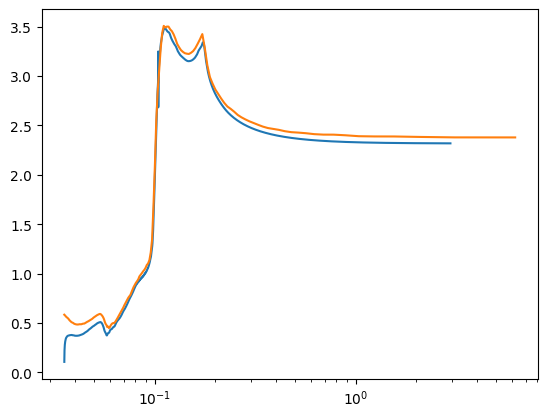

In [97]:
n_integrated_wavelength_array = np.flip(np.concatenate(((2*np.pi*c/modified_omega_values).reshape((-1,1)), n_integrated_omega.reshape((-1, 1))), axis=1), axis=0)
#Flip back again to undo the ordering change from division
print(n_integrated_wavelength_array)

plt.semilogx(n_integrated_wavelength_array[:,0], n_integrated_wavelength_array[:,1], label="calculated values")
plt.semilogx(n_array[:,0], n_array[:, 1], label="actual values")
plt.show()
# k_array_omega = np.concatenate((2*np.pi*c/(k_array[:, 0]).reshape((-1, 1)), k_array[:, 1].reshape(-1,1)), axis=1)
# n_array_omega = np.concatenate((2*np.pi*c/(n_array[:, 0]).reshape((-1, 1)), n_array[:, 1].reshape(-1,1)), axis=1)

Now that we've done this, let's make a properly labeled plot of n(calculated) and k vs frequency.

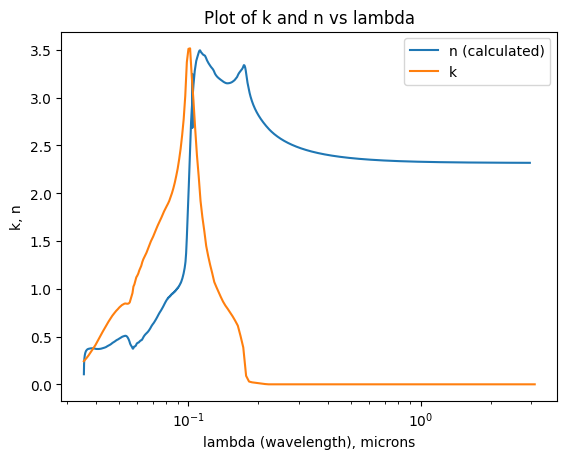

In [98]:
plt.semilogx(n_integrated_wavelength_array[:,0], n_integrated_wavelength_array[:,1], label="n (calculated)")
plt.semilogx(k_array[:,0], k_array[:,1], label = "k")
plt.title("Plot of k and n vs lambda")
plt.xlabel("lambda (wavelength), microns")
plt.ylabel("k, n")
plt.legend()
plt.show()

Let's now plot and quantify the agreement between the calculated values and the given values. The quantifying will be done by taking the RMS difference, which is a pretty natural choice.

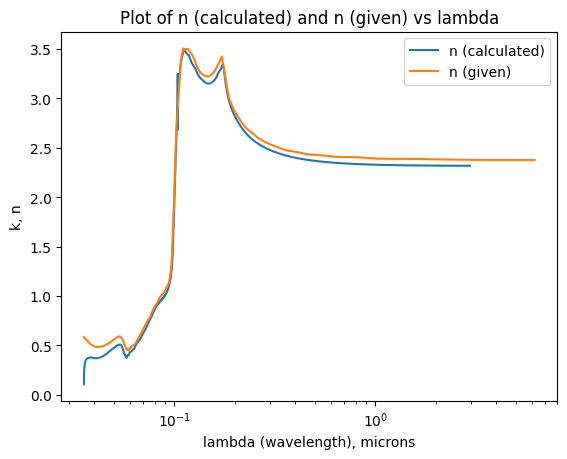

In [99]:
plt.semilogx(n_integrated_wavelength_array[:,0], n_integrated_wavelength_array[:,1], label="n (calculated)")
plt.semilogx(n_array[:,0], n_array[:,1], label = "n (given)")
plt.title("Plot of n (calculated) and n (given) vs lambda")
plt.xlabel("lambda (wavelength), microns")
plt.ylabel("k, n")
plt.legend()
plt.show()

In [100]:
#### Scratch work cell
print(len(n_array))
print(len(n_integrated_wavelength_array))

# print(n_wavelength_integrated[:,0])

## These two lengths are not the same, so a naive simpson application will not
## work. We will have to interpolate the n_array to the wavelengths at which we
## calculated our n through the numerical integration
## (this is the the [:,0] index of n_wavelength_integrated)
## before integrating point-by-point
n_interp_wavelength = np.interp(n_integrated_wavelength_array[:, 0].astype(np.float64), n_array[:, 0].astype(np.float64), n_array[:, 1].astype(np.float64))
n_interp_wavelength_array = np.concatenate((np.reshape(n_integrated_wavelength_array[:,0], (-1,1)),np.reshape(n_interp_wavelength,(-1,1))),axis=1)

# print(n_interp_wavelength_array[:,0])
# print(n_integrated_wavelength_array[:,0])

## Good!
visible_lower_index = np.min(np.where(n_integrated_wavelength_array[:,0]>=0.4))
## returns entry 205
visible_upper_index = np.max(np.where(n_integrated_wavelength_array[:,0]<=0.7))

print(visible_lower_index)
## returns entry 404
# Visible is between entries 205 and 404

175
5220
4815


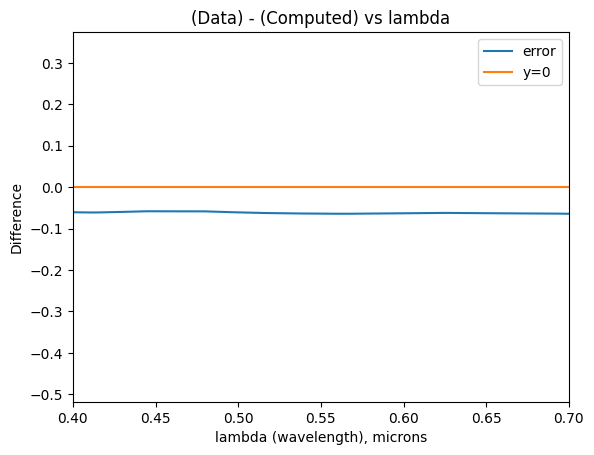

In [101]:
plt.plot(n_integrated_wavelength_array[:,0], n_integrated_wavelength_array[:,1]-n_interp_wavelength_array[:,1], label="error")
plt.plot(n_integrated_wavelength_array[:,0], np.zeros(len(n_integrated_wavelength_array)), label="y=0")
plt.title("(Data) - (Computed) vs lambda")
plt.xlabel("lambda (wavelength), microns")
plt.xlim((0.4, 0.7))
plt.ylabel("Difference")
plt.legend()
plt.show()

In [102]:
## Error over the whole range
error = np.sqrt(1/(n_integrated_wavelength_array[-1,0] - n_integrated_wavelength_array[1,0])*(simpson((n_interp_wavelength_array[:,1] - n_integrated_wavelength_array[:,1])**2, n_integrated_wavelength_array[:,0])))
print("Error over whole range:",error)

## Error over visible spectrum
error = np.sqrt(1/(n_integrated_wavelength_array[visible_upper_index,0] - n_integrated_wavelength_array[visible_lower_index,0])*(simpson((n_interp_wavelength_array[visible_lower_index:visible_upper_index,1] - n_integrated_wavelength_array[visible_lower_index:visible_upper_index,1])**2, n_integrated_wavelength_array[visible_lower_index:visible_upper_index,0])))
print("Error over visible range:",error)

Error over whole range: 0.063967764355229622915
Error over visible range: 0.06158843453720475249


Our RMS error is
$$Error_{RMS} = \sqrt{\frac{1}{\lambda_{max} - \lambda_{min}} \int_{\lambda_{min}}^{\lambda_{max}} \left (n_{calculated}(\lambda') - n_{given}(\lambda')\right)^2 d \lambda'}$$
$$ = 0.064 $$
This is likely due to the long tail from 0.5 microns to 3.0 microns, for which the calculated value is just consistently smaller than the given value. I think this disagreement is due to the fact that we did not actually integrate from $0$ to $\infty$ when computing the Kramers-Kronig integral. In other words, the *early truncation* causes the computed value to be consistently lower than the given value.


For the visible range, the error is
$$Error_{RMS} = \sqrt{\frac{1}{0.7 \mu m - 0.4 \mu m} \int_{0.4 \mu m}^{0.7 \mu m} \left (n_{calculated}(\lambda') - n_{given}(\lambda')\right)^2 d \lambda'}$$
$$=0.062$$

Let's now artificially set the UV band of the $k$-value to $0$.

In [103]:
# #### This is terrible code practice to overwrite variables, but I didn't set
# #### the integrator up as a function, so this is the fastest way.
# k_array = np.concatenate((np.reshape(k_array[:,0],(-1,1)),np.reshape(np.where(k_array[:,0]<=0.23,0,k_array[:,1]),(-1,1))),axis=1)
# k_array_omega = np.concatenate((2*np.pi*c/(k_array[:, 0]).reshape((-1, 1)), k_array[:, 1].reshape(-1,1)), axis=1)

# interp_k = np.interp(x_values.astype(np.float64), np.flip(k_array_omega[:, 0].astype(np.float64)), np.flip(k_array_omega[:, 1].astype(np.float64)))
# interp_k_array = np.concatenate((np.reshape(x_values, (-1,1)),np.reshape(interp_k,(-1,1))),axis=1)

In [104]:
UV_upper_wavelength = 0.23

modified_k = np.reshape(np.where(k_array[:,0]<=UV_upper_wavelength,0,k_array[:,1]),(-1,1))
modified_k_array = np.concatenate((np.reshape(k_array[:,0],(-1,1)),modified_k),axis=1)
# print(modified_k_array)
# We have set the entire absorption band to 0, so the k value is 0 throughout the whole range.

modified_k_omega_array = np.flip(np.concatenate((2*np.pi*c/(modified_k_array[:, 0]).reshape((-1, 1)), modified_k_array[:, 1].reshape(-1,1)), axis=1),axis=0)

modified_interp_k = np.interp(omega_values.astype(np.float64), modified_k_array[:, 0].astype(np.float64), modified_k_array[:, 1].astype(np.float64))
# modified_interp_k_array = np.concatenate((np.reshape(omega_values, (-1,1)),np.reshape(modified_interp_k,(-1,1))),axis=1)

cannot select an axis to squeeze out which has size not equal to one
cannot select an axis to squeeze out which has size not equal to one
cannot select an axis to squeeze out which has size not equal to one
cannot select an axis to squeeze out which has size not equal to one
cannot select an axis to squeeze out which has size not equal to one
cannot select an axis to squeeze out which has size not equal to one


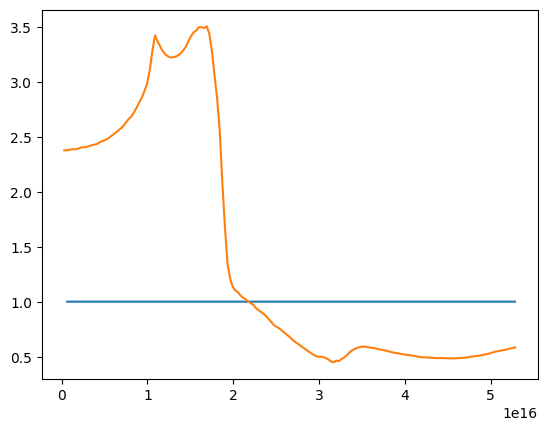

In [112]:
## So this is horrible and ugly because I didn't do this as a function earlier.
## If I need this code in the future, I'll refactor it then.

n_modified_omega = np.array([])
delete_omega_values = np.array([])

for i in range(len(omega_values)):
  try:
    omega = omega_values[i]

    #mask out the x values which are within +- 3x10^13 of our pole
    left_mask = ~((omega_values < omega + 3e13))
    right_mask = ~((omega_values> omega - 3e13))

    #Integrate from -oo to the left mask and the right mask to oo
    x_right = omega_values[right_mask]
    y_right = (modified_interp_k[right_mask]*omega_values[right_mask])/(omega_values[right_mask]**2 - omega**2)

    x_left = omega_values[left_mask]
    y_left = (modified_interp_k[left_mask]*omega_values[left_mask])/(omega_values[left_mask]**2 - omega**2)


    n_modified_omega = np.append(n_modified_omega, 1+ 2/np.pi*(simpson(y_right,x_right) + simpson(y_left, x_left)))
  except Exception as e:
    print(e)
    # if we get an error, one of the masks has blocked off *all* of the x values.
    # We add that x value to a list that will later be removed.
    delete_omega_values = np.append(delete_omega_values,i)

#remove the flagged x values
modified_omega_values = np.delete(omega_values, delete_omega_values.astype(int))

plt.plot(modified_omega_values, n_modified_omega, label="modified n")
plt.plot(n_array_omega[:,0], n_array_omega[:, 1], label="original n")
plt.show()

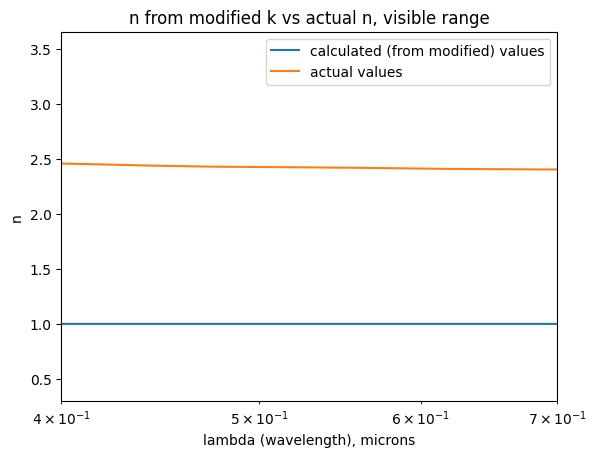

In [113]:
n_wavelength_modified = np.concatenate(((2*np.pi*c/modified_omega_values).reshape((-1,1)), n_modified_omega.reshape((-1, 1))), axis=1)


plt.title("n from modified k vs actual n, visible range")
plt.semilogx(n_wavelength_modified[:,0], n_wavelength_modified[:,1], label="calculated (from modified) values")
plt.semilogx(n_array[:,0], n_array[:, 1], label="actual values")
plt.xlabel("lambda (wavelength), microns")
plt.xlim((0.4,0.7))
plt.ylabel("n")
plt.legend()
plt.show()

In [115]:
## Error over visible spectrum
error = np.sqrt(1/(n_wavelength_modified[404,0] - n_wavelength_modified[205,0])*(simpson((n_interp_wavelength_array[205:404,1] - n_wavelength_modified[205:404,1])**2, n_wavelength_modified[205:404,0])))
print("Error over visible range:",error)

Error over visible range: 0.46744766803495706888


Ok I think the point is pretty clear:

The physical origin of the high index of refraction (visible range) of diamond comes from its high extinction coefficient in the UV range. We quantify this relationship by the Kramers Kronig relations.